---
## 1. Model Parameters

### 1.1 Portfolio composition

The evaluation pipeline serves two customer types:

| Customer type | Proportion | Stage 5 service time | Source |
|---------------|------------|----------------------|--------|
| Small firm    | p = 0.70   | S_small = 72 h       | Empirical (anonymized case, information-scarce) |
| Mid-size firm | 1-p = 0.30 | S_large = 5 h        | Empirical (anonymized case, information-rich) |

### 1.2 Rationale for M/G/1

Service time S follows a **two-point mixture distribution**, not exponential.  
sigma[S] ~= 30.7 h (computed below) violates the M/M/1 memoryless assumption.  
The **Pollaczek-Khinchine (P-K) formula** for M/G/1 is therefore required.

### 1.3 Alpha (XAI efficiency gain) — three-layer justification

alpha quantifies how much XAI assistance reduces Stage 5 service time.  
It is **not** drawn from a single literature value but justified across three layers:

| Layer | Source | Value | Role |
|-------|--------|-------|------|
| Empirical upper bound | Stage 7 pipeline: human 30 min -> LLM 5 min | alpha = 5.0 | Ceiling for full AI substitution |
| Conservative lower bound | Becker et al. (2025): AI-assisted productivity +19% | alpha = 0.19 | Floor for partial assistance |
| Conservative lower bound | Schemmer et al. (2022): meta-analysis XAI on decision tasks | alpha ~= 0.2-0.5 | Floor for decision-task XAI effect |
| S2 scenario anchor | Between lower and upper bounds | alpha = 1.94 | Partial XAI deployment |
| S3 scenario anchor | Approaching empirical upper bound | alpha = 8.58 | Full XAI deployment |

**Conceptual sources (framework, not alpha values):**  
- Arrieta et al. (2020): defines the class of post-hoc, model-agnostic XAI methods applicable to Stage 5  
- Karimi et al. (2022): counterfactual recourse formalism structuring XAI outputs for human reviewers


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Output directory ──────────────────────────────────────────────────────────
FIG_DIR = Path("figures")
TAB_DIR = Path("tables")
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DPI = 600
print("Environment ready.")


Environment ready.


---
## 1. Model Parameters

### 1.1 Portfolio composition

The evaluation pipeline serves two customer types:

| Customer type | Proportion | Stage ⑤ service time | Source |
|---------------|------------|----------------------|--------|
| Small firm    | p = 0.70   | S_small = 72 h       | Empirical (anonymized case) |
| Mid-size firm | 1−p = 0.30 | S_large = 5 h        | Empirical (anonymized case) |

### 1.2 Rationale for M/G/1

Service time S follows a **two-point mixture distribution**, not exponential.  
σ[S] ≈ 30.7 h (computed below) violates the M/M/1 memoryless assumption.  
The **Pollaczek-Khinchine (P-K) formula** for M/G/1 is therefore required.


In [2]:
# ── Portfolio parameters ─────────────────────────────────────────────────────
p_small = 0.70   # proportion of small-firm requests
p_large = 0.30   # proportion of mid-size-firm requests

# ── Scenario service times (Stage ⑤, hours) ──────────────────────────────────
SCENARIOS = {
    "S1 (No XAI)":      {"s_small": 72.0, "s_large": 5.0},
    "S2 (Partial XAI)": {"s_small": 24.0, "s_large": 3.0},
    "S3 (Full XAI)":    {"s_small":  8.0, "s_large": 1.5},
}

# ── Helper: mixed service time moments ───────────────────────────────────────
def service_moments(s_small, s_large):
    """
    Compute E[S], E[S^2], Var[S], sigma[S] for the two-point mixture.
    Parameters
    ----------
    s_small : float  Mean service time for small firms (hours)
    s_large : float  Mean service time for mid-size firms (hours)
    Returns
    -------
    dict with ES, ES2, VarS, sigmaS, mu
    """
    ES    = p_small * s_small + p_large * s_large
    ES2   = p_small * s_small**2 + p_large * s_large**2
    VarS  = ES2 - ES**2
    sigma = np.sqrt(VarS)
    mu    = 1.0 / ES          # service rate (jobs/hour)
    return dict(ES=ES, ES2=ES2, VarS=VarS, sigmaS=sigma, mu=mu)

# ── Compute for all scenarios ─────────────────────────────────────────────────
moments = {name: service_moments(**v) for name, v in SCENARIOS.items()}

for name, m in moments.items():
    print(f"{name}")
    print(f"  E[S]    = {m['ES']:.2f} h")
    print(f"  E[S^2]  = {m['ES2']:.2f}")
    print(f"  Var[S]  = {m['VarS']:.2f}")
    print(f"  sigma   = {m['sigmaS']:.2f} h")
    print(f"  mu      = {m['mu']:.5f} jobs/h")
    print()


S1 (No XAI)
  E[S]    = 51.90 h
  E[S^2]  = 3636.30
  Var[S]  = 942.69
  sigma   = 30.70 h
  mu      = 0.01927 jobs/h

S2 (Partial XAI)
  E[S]    = 17.70 h
  E[S^2]  = 405.90
  Var[S]  = 92.61
  sigma   = 9.62 h
  mu      = 0.05650 jobs/h

S3 (Full XAI)
  E[S]    = 6.05 h
  E[S^2]  = 45.47
  Var[S]  = 8.87
  sigma   = 2.98 h
  mu      = 0.16529 jobs/h



---
## 2. M/G/1 Analytics — Pollaczek-Khinchine Formula

For an M/G/1 queue with arrival rate λ and general service time S:

$$\rho = \lambda \cdot E[S]$$

$$W_q = \frac{\lambda \cdot E[S^2]}{2(1 - \rho)}$$

$$L_q = \lambda \cdot W_q$$

Stability condition: **ρ < 1**, i.e., λ < μ = 1/E[S]


In [3]:
# ── Pollaczek-Khinchine functions ────────────────────────────────────────────

def utilization(lam, ES):
    """Traffic intensity rho = lambda * E[S]"""
    return lam * ES

def mean_waiting_time(lam, ES, ES2):
    """
    P-K mean waiting time in queue (hours).
    Returns np.inf when rho >= 1 (unstable).
    """
    rho = utilization(lam, ES)
    if np.isscalar(lam):
        return np.inf if rho >= 1 else (lam * ES2) / (2 * (1 - rho))
    Wq = np.where(rho < 1, (lam * ES2) / (2 * (1 - rho)), np.inf)
    return Wq

def mean_queue_length(lam, Wq):
    """Little's Law: Lq = lambda * Wq"""
    return lam * Wq

def throughput_weekly(mu, hours_per_day=8, days_per_week=5):
    """Maximum stable throughput (jobs/week)"""
    return mu * hours_per_day * days_per_week

# ── Spot-check at representative lambda ──────────────────────────────────────
lam_test = 0.010   # jobs/hour (below S1 stability threshold)

print(f"Spot-check at λ = {lam_test:.3f} jobs/h")
print(f"{'Scenario':<22} {'rho':>6} {'Wq (h)':>10} {'Lq':>8}")
print("-" * 50)
for name, m in moments.items():
    rho = utilization(lam_test, m['ES'])
    Wq  = mean_waiting_time(lam_test, m['ES'], m['ES2'])
    Lq  = mean_queue_length(lam_test, Wq)
    print(f"{name:<22} {rho:>6.3f} {Wq:>10.2f} {Lq:>8.4f}")


Spot-check at λ = 0.010 jobs/h
Scenario                  rho     Wq (h)       Lq
--------------------------------------------------
S1 (No XAI)             0.519      37.80   0.3780
S2 (Partial XAI)        0.177       2.47   0.0247
S3 (Full XAI)           0.060       0.24   0.0024


---
## 3. Scenario Comparison

Three scenarios differ in the XAI assistance level applied to Stage ⑤ (pricing decision):

| Scenario | XAI coverage | Small-firm service time | Mid-size service time |
|----------|-------------|-------------------------|-----------------------|
| S1       | None (baseline) | 72 h | 5 h |
| S2       | Partial (high-risk only) | 24 h | 3 h |
| S3       | Full (all outputs) | 8 h | 1.5 h |


In [4]:
# ── Table 1: Scenario parameter summary ──────────────────────────────────────

rows = []
for name, v in SCENARIOS.items():
    m = moments[name]
    alpha = (1.0 / m['ES']) / moments['S1 (No XAI)']['mu'] - 1  # XAI efficiency gain
    weekly = throughput_weekly(m['mu'])
    rows.append({
        "Scenario":              name,
        "s_small (h)":           v['s_small'],
        "s_large (h)":           v['s_large'],
        "E[S] (h)":              round(m['ES'],    2),
        "Var[S]":                round(m['VarS'],  2),
        "sigma[S] (h)":          round(m['sigmaS'],2),
        "mu (jobs/h)":           round(m['mu'],    5),
        "alpha (XAI gain)":      round(alpha,      3),
        "Throughput (jobs/wk)":  round(weekly,     2),
    })

df_summary = pd.DataFrame(rows).set_index("Scenario")
print("=== Table 1: M/G/1 Scenario Parameter Summary ===")
print(df_summary.to_string())

# Save as CSV
df_summary.to_csv(TAB_DIR / "table1_scenario_parameters.csv")
print(f"\nSaved → {TAB_DIR}/table1_scenario_parameters.csv")


=== Table 1: M/G/1 Scenario Parameter Summary ===
                  s_small (h)  s_large (h)  E[S] (h)  Var[S]  sigma[S] (h)  mu (jobs/h)  alpha (XAI gain)  Throughput (jobs/wk)
Scenario                                                                                                                       
S1 (No XAI)              72.0          5.0     51.90  942.69         30.70      0.01927             0.000                  0.77
S2 (Partial XAI)         24.0          3.0     17.70   92.61          9.62      0.05650             1.932                  2.26
S3 (Full XAI)             8.0          1.5      6.05    8.87          2.98      0.16529             7.579                  6.61

Saved → tables/table1_scenario_parameters.csv


In [5]:
# ── Table 2: Stability threshold and capacity comparison ─────────────────────

rows2 = []
for name, m in moments.items():
    weekly = throughput_weekly(m['mu'])
    rows2.append({
        "Scenario":                       name,
        "Stability threshold lambda* (jobs/h)": round(m['mu'], 5),
        "Max stable arrivals (jobs/day)": round(m['mu'] * 8, 4),
        "Max stable arrivals (jobs/wk)":  round(weekly, 2),
        "Capacity ratio vs S1":           round(m['mu'] / moments['S1 (No XAI)']['mu'], 2),
    })

df_stability = pd.DataFrame(rows2).set_index("Scenario")
print("=== Table 2: Stability Thresholds and Throughput ===")
print(df_stability.to_string())

df_stability.to_csv(TAB_DIR / "table2_stability_thresholds.csv")
print(f"\nSaved → {TAB_DIR}/table2_stability_thresholds.csv")


=== Table 2: Stability Thresholds and Throughput ===
                  Stability threshold lambda* (jobs/h)  Max stable arrivals (jobs/day)  Max stable arrivals (jobs/wk)  Capacity ratio vs S1
Scenario                                                                                                                                   
S1 (No XAI)                                    0.01927                          0.1541                           0.77                  1.00
S2 (Partial XAI)                               0.05650                          0.4520                           2.26                  2.93
S3 (Full XAI)                                  0.16529                          1.3223                           6.61                  8.58

Saved → tables/table2_stability_thresholds.csv


---
## 4. Figures

Three figures for the paper:

- **Figure 1** — Traffic intensity ρ vs arrival rate λ (all scenarios)  
- **Figure 2** — Mean waiting time Wq vs λ (all scenarios, log scale)  
- **Figure 3** — Weekly throughput comparison by scenario (bar chart)


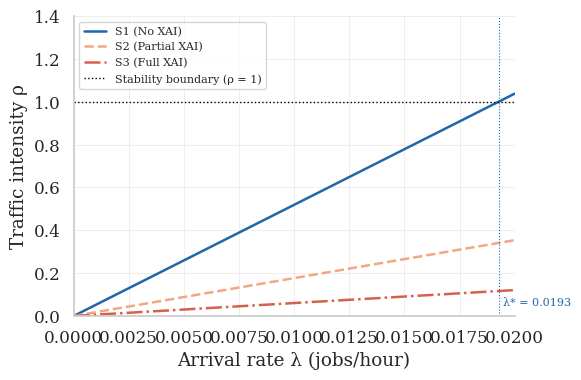

Saved → figures/fig1_rho_vs_lambda.png


In [6]:
# ── Figure 1: Traffic intensity (rho) vs arrival rate (lambda) ───────────────

colors    = ["#2166ac", "#f4a582", "#d6604d"]   # blue / orange / red
styles    = ["-", "--", "-."]
lam_range = np.linspace(0, 0.020, 500)          # spans S1 stability region

fig, ax = plt.subplots(figsize=(6, 4))

for (name, m), color, ls in zip(moments.items(), colors, styles):
    rho = utilization(lam_range, m['ES'])
    ax.plot(lam_range, rho, label=name, color=color, linestyle=ls, linewidth=1.8)

# Stability boundary
ax.axhline(1.0, color="black", linewidth=1.0, linestyle=":", label="Stability boundary (ρ = 1)")

# Annotate critical lambda for S1
mu_s1 = moments['S1 (No XAI)']['mu']
ax.axvline(mu_s1, color=colors[0], linewidth=0.8, linestyle=":")
ax.text(mu_s1 + 0.0002, 0.05, f"λ* = {mu_s1:.4f}", fontsize=8, color=colors[0])

ax.set_xlabel("Arrival rate λ (jobs/hour)")
ax.set_ylabel("Traffic intensity ρ")
ax.set_xlim(0, 0.020)
ax.set_ylim(0, 1.4)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_rho_vs_lambda.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig1_rho_vs_lambda.png")


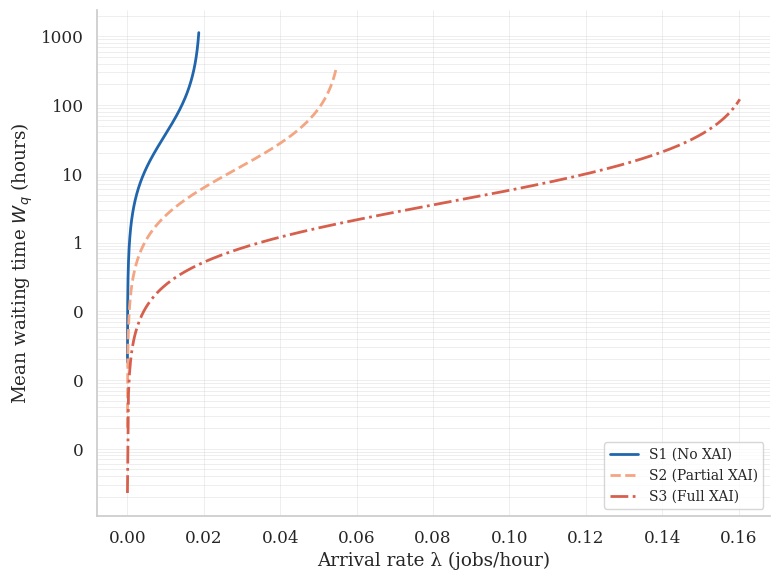

Saved → figures/fig2_Wq_vs_lambda.png


In [7]:
# ── Figure 2: Mean waiting time Wq vs arrival rate λ ─────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

for (name, m), color, ls in zip(moments.items(), colors, styles):
    mu  = m['mu']
    # Use 95% of stability range to avoid divergence artifact
    lam = np.linspace(1e-5, mu * 0.97, 600)
    Wq  = mean_waiting_time(lam, m['ES'], m['ES2'])
    ax.plot(lam, Wq, label=name, color=color, linestyle=ls, linewidth=2.0)

ax.set_xlabel("Arrival rate λ (jobs/hour)")
ax.set_ylabel("Mean waiting time $W_q$ (hours)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, which="both", linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_Wq_vs_lambda.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig2_Wq_vs_lambda.png")


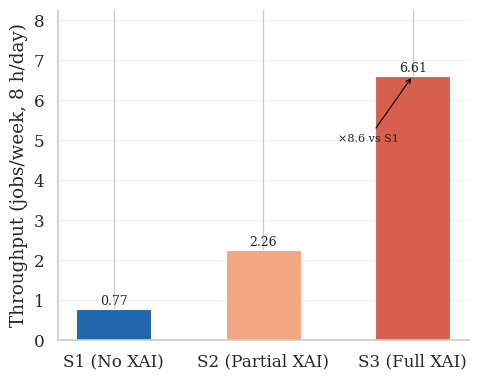

Saved → figures/fig3_throughput_comparison.png


In [8]:
# ── Figure 3: Weekly throughput by scenario ──────────────────────────────────

scenario_labels = list(moments.keys())
throughputs     = [throughput_weekly(m['mu']) for m in moments.values()]
bar_colors      = ["#2166ac", "#f4a582", "#d6604d"]

fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(scenario_labels, throughputs, color=bar_colors,
              width=0.5, edgecolor="white", linewidth=0.8)

# Value labels on bars
for bar, val in zip(bars, throughputs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{val:.2f}",
        ha="center", va="bottom", fontsize=9
    )

# Capacity ratio annotation
ratio = throughputs[-1] / throughputs[0]
ax.annotate(
    f"×{ratio:.1f} vs S1",
    xy=(2, throughputs[2]),
    xytext=(1.5, throughputs[2] * 0.75),
    arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
    fontsize=8
)

ax.set_ylabel("Throughput (jobs/week, 8 h/day)")
ax.set_ylim(0, max(throughputs) * 1.25)
ax.grid(axis="y", linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_throughput_comparison.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig3_throughput_comparison.png")


In [9]:
# ── Table 3: P-K results at representative lambda values ─────────────────────
# Use lambdas = 30%, 60%, 90% of S1 stability threshold

mu_s1 = moments['S1 (No XAI)']['mu']
lambda_levels = {
    "30% of λ* (S1)": mu_s1 * 0.30,
    "60% of λ* (S1)": mu_s1 * 0.60,
    "90% of λ* (S1)": mu_s1 * 0.90,
}

rows3 = []
for lam_label, lam in lambda_levels.items():
    for name, m in moments.items():
        rho = utilization(lam, m['ES'])
        Wq  = mean_waiting_time(lam, m['ES'], m['ES2'])
        Lq  = mean_queue_length(lam, Wq) if not np.isinf(Wq) else np.inf
        rows3.append({
            "lambda level":  lam_label,
            "lambda (jobs/h)": round(lam, 6),
            "Scenario":      name,
            "rho":           round(rho, 4),
            "Wq (h)":        round(Wq, 2) if not np.isinf(Wq) else "unstable",
            "Lq":            round(Lq, 4) if not np.isinf(Lq) else "unstable",
        })

df_pk = pd.DataFrame(rows3)
print("=== Table 3: P-K Results at Representative Arrival Rates ===")
print(df_pk.to_string(index=False))

df_pk.to_csv(TAB_DIR / "table3_PK_results.csv", index=False)
print(f"\nSaved → {TAB_DIR}/table3_PK_results.csv")


=== Table 3: P-K Results at Representative Arrival Rates ===
  lambda level  lambda (jobs/h)         Scenario    rho  Wq (h)     Lq
30% of λ* (S1)         0.005780      S1 (No XAI) 0.3000   15.01 0.0868
30% of λ* (S1)         0.005780 S2 (Partial XAI) 0.1023    1.31 0.0076
30% of λ* (S1)         0.005780    S3 (Full XAI) 0.0350    0.14 0.0008
60% of λ* (S1)         0.011561      S1 (No XAI) 0.6000   52.55 0.6075
60% of λ* (S1)         0.011561 S2 (Partial XAI) 0.2046    2.95 0.0341
60% of λ* (S1)         0.011561    S3 (Full XAI) 0.0699    0.28 0.0033
90% of λ* (S1)         0.017341      S1 (No XAI) 0.9000  315.29 5.4674
90% of λ* (S1)         0.017341 S2 (Partial XAI) 0.3069    5.08 0.0881
90% of λ* (S1)         0.017341    S3 (Full XAI) 0.1049    0.44 0.0076

Saved → tables/table3_PK_results.csv


---
## 5. Summary

| Finding | Value |
|---------|-------|
| Baseline service time E[S] | 51.9 h (S1) |
| Service time std dev σ[S]  | 30.7 h — justifies M/G/1 over M/M/1 |
| Baseline throughput        | 0.77 jobs/week (S1) |
| Full-XAI throughput        | 6.61 jobs/week (S3) |
| Throughput gain S1 → S3    | ×8.6 |
| Critical arrival rate λ* (S1) | 0.01927 jobs/h |
| Critical arrival rate λ* (S3) | 0.16529 jobs/h |

**Next notebook:** `02_simulation_scenarios.ipynb` — SimPy discrete-event simulation to validate these analytical results.
